In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

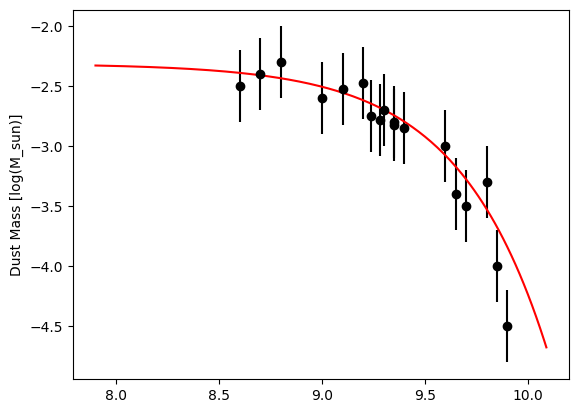

In [ ]:
### new things above - plotting synthetic observations and function

md_obs = np.array([-2.3, -2.4, -2.5, -2.6, - 2.52, - 2.47, 
          -2.7, -2.8, -2.75, -2.78, -2.82, -2.85,
          - 3.0, -3.4, -3.5, -3.3, -4.0, -4.5])

ages_obs = np.array([8.8, 8.7, 8.6, 9.0, 9.1, 9.2,
            9.3, 9.35, 9.24, 9.28, 9.35, 9.4,
            9.6, 9.65, 9.7, 9.8, 9.85, 9.9])

sigmas = np.full_like(md_obs, 0.3)

fig, ax = plt.subplots()
ax.errorbar(ages_obs, md_obs, c="black", yerr=sigmas, fmt='o')
ax.set_ylabel('Dust Mass [log(M_sun)]')

x = np.arange(7.9, 10.1, 0.01)
a_all = 2.31
b_all = 2.26 
y = ((-(10**x)/10**9) / b_all)*np.log10(2.7182) - a_all
ax.plot(x, y, c="red", label="Best fit")


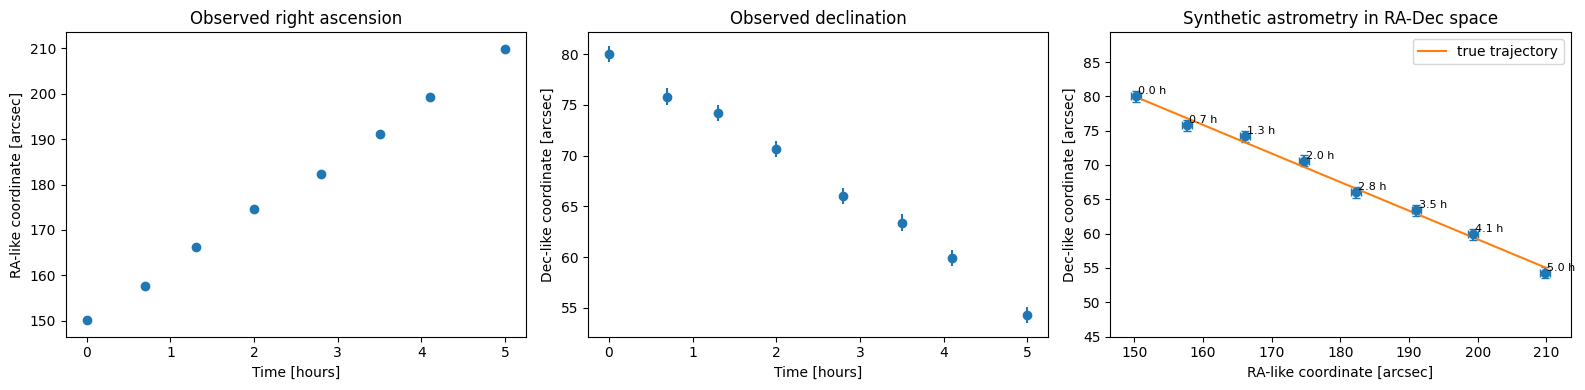

In [ ]:
#plot synthetic data
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# axes[0].errorbar(t, alpha_obs, yerr=sigma_alpha, fmt="o")
# axes[0].set_xlabel("Time [hours]")
# axes[0].set_ylabel("RA-like coordinate [arcsec]")
# axes[0].set_title("Observed right ascension")

# axes[1].errorbar(t, delta_obs, yerr=sigma_delta, fmt="o")
# axes[1].set_xlabel("Time [hours]")
# axes[1].set_ylabel("Dec-like coordinate [arcsec]")
# axes[1].set_title("Observed declination")

# axes[2].errorbar(alpha_obs, delta_obs, xerr=sigma_alpha, yerr=sigma_delta, fmt="o", capsize=3)
# axes[2].plot(
#     alpha0_true + mu_alpha_true * (t - t0),
#     delta0_true + mu_delta_true * (t - t0),
#     label="true trajectory"
# )
# for i, ti in enumerate(t):
#     axes[2].text(alpha_obs[i] + 0.3, delta_obs[i] + 0.3, f"{ti:.1f} h", fontsize=8)

# axes[2].set_xlabel("RA-like coordinate [arcsec]")
# axes[2].set_ylabel("Dec-like coordinate [arcsec]")
# axes[2].set_title("Synthetic astrometry in RA-Dec space")
# axes[2].axis("equal")
# axes[2].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
#Weighted least-squares solution for initialization
# Observation vector
y = np.empty(2 * len(md_obs))
y[0::2] = ages_obs
y[1::2] = md_obs

# Design matrix
A = np.zeros((2 * len(t), 4))
dt = t - t0

A[0::2, 0] = 1.0
A[0::2, 2] = dt

A[1::2, 1] = 1.0
A[1::2, 3] = dt

# Weight matrix
w = np.empty(2 * len(t))
w[0::2] = 1.0 / sigma_alpha**2
w[1::2] = 1.0 / sigma_delta**2
W = np.diag(w)

# Weighted LS solution
ATWA = A.T @ W @ A
ATWy = A.T @ W @ y
theta_hat = np.linalg.solve(ATWA, ATWy)
cov_hat = np.linalg.inv(ATWA)

alpha0_hat, delta0_hat, mu_alpha_hat, mu_delta_hat = theta_hat
sigma_theta_hat = np.sqrt(np.diag(cov_hat))

print("Weighted least-squares estimate:")
print(f"alpha0   = {alpha0_hat:.4f} ± {sigma_theta_hat[0]:.4f} arcsec")
print(f"delta0   = {delta0_hat:.4f} ± {sigma_theta_hat[1]:.4f} arcsec")
print(f"mu_alpha = {mu_alpha_hat:.4f} ± {sigma_theta_hat[2]:.4f} arcsec/hour")
print(f"mu_delta = {mu_delta_hat:.4f} ± {sigma_theta_hat[3]:.4f} arcsec/hour")

Weighted least-squares estimate:
alpha0   = 150.0182 ± 0.4452 arcsec
delta0   = 80.1589 ± 0.5088 arcsec
mu_alpha = 11.9028 ± 0.1526 arcsec/hour
mu_delta = -5.0000 ± 0.1744 arcsec/hour


In [ ]:
#priors
# Independent Gaussian priors centered on the LS solution
# This is convenient for the notebook and makes the posterior compact.

prior_mean = theta_hat.copy()
prior_std = np.array([8.0, 8.0, 8.0, 8.0])

def log_prior(theta):
    """
    Log prior for a single parameter vector theta = [alpha0, delta0, mu_alpha, mu_delta].
    """
    z = (theta - prior_mean) / prior_std
    return -0.5 * np.sum(z**2) - np.sum(np.log(prior_std)) - 0.5 * 4 * np.log(2 * np.pi)

In [ ]:
# Forward model
def model_prediction(theta, t, t0=0.0):
    """
    Model prediction for a single parameter vector theta.
    """
    alpha0, delta0, mu_alpha, mu_delta = theta
    alpha_model = alpha0 + mu_alpha * (t - t0)
    delta_model = delta0 + mu_delta * (t - t0)
    return alpha_model, delta_model

In [ ]:
#likelihood and posterior
def log_likelihood(theta, t, alpha_obs, delta_obs, sigma_alpha, sigma_delta, t0=0.0):
    """
    Gaussian log-likelihood for a single parameter vector theta.
    """
    alpha_model, delta_model = model_prediction(theta, t, t0=t0)

    chi2_alpha = np.sum(((alpha_obs - alpha_model) / sigma_alpha)**2)
    chi2_delta = np.sum(((delta_obs - delta_model) / sigma_delta)**2)

    log_norm_alpha = -np.sum(np.log(sigma_alpha)) - 0.5 * len(t) * np.log(2 * np.pi)
    log_norm_delta = -np.sum(np.log(sigma_delta)) - 0.5 * len(t) * np.log(2 * np.pi)

    return log_norm_alpha + log_norm_delta - 0.5 * (chi2_alpha + chi2_delta)

def log_posterior(theta, t, alpha_obs, delta_obs, sigma_alpha, sigma_delta, t0=0.0):
    """
    Log posterior = log prior + log likelihood
    """
    return log_prior(theta) + log_likelihood(theta, t, alpha_obs, delta_obs, sigma_alpha, sigma_delta, t0=t0)

# **Metropolis–Hastings sampler**

In [ ]:
def metropolis_hastings(
    log_posterior_func,
    theta0,
    proposal_std,
    n_steps,
    t,
    alpha_obs,
    delta_obs,
    sigma_alpha,
    sigma_delta,
    t0=0.0,
    rng=None
):
    """
    Random-walk Metropolis-Hastings sampler.

    Parameters
    ----------
    log_posterior_func : function
        Function returning log posterior for a single theta.
    theta0 : array-like, shape (4,)
        Initial state.
    proposal_std : array-like, shape (4,)
        Standard deviations of Gaussian proposal steps.
    n_steps : int
        Number of MCMC iterations.
    rng : numpy random generator

    Returns
    -------
    chain : ndarray, shape (n_steps, 4)
    logpost_chain : ndarray, shape (n_steps,)
    accepted : ndarray, shape (n_steps,)
        Boolean array indicating whether proposal was accepted.
    """
    if rng is None:
        rng = np.random.default_rng()

    theta_current = np.array(theta0, dtype=float)
    logp_current = log_posterior_func(
        theta_current, t, alpha_obs, delta_obs, sigma_alpha, sigma_delta, t0=t0
    )

    chain = np.zeros((n_steps, len(theta_current)))
    logpost_chain = np.zeros(n_steps)
    accepted = np.zeros(n_steps, dtype=bool)

    for i in range(n_steps):
        # Symmetric Gaussian random-walk proposal
        theta_proposal = theta_current + rng.normal(0.0, proposal_std, size=len(theta_current))

        logp_proposal = log_posterior_func(
            theta_proposal, t, alpha_obs, delta_obs, sigma_alpha, sigma_delta, t0=t0
        )

        log_accept_ratio = logp_proposal - logp_current

        if np.log(rng.uniform()) < log_accept_ratio:
            theta_current = theta_proposal
            logp_current = logp_proposal
            accepted[i] = True

        chain[i] = theta_current
        logpost_chain[i] = logp_current

    return chain, logpost_chain, accepted

In [ ]:
# Run the MCMC
# Initial state: least-squares estimate
theta0 = theta_hat.copy()

# Proposal widths: tune if needed
proposal_std = np.array([0.15, 0.15, 0.08, 0.08])

# Number of iterations
n_steps = 120_000

chain, logpost_chain, accepted = metropolis_hastings(
    log_posterior_func=log_posterior,
    theta0=theta0,
    proposal_std=proposal_std,
    n_steps=n_steps,
    t=t,
    alpha_obs=alpha_obs,
    delta_obs=delta_obs,
    sigma_alpha=sigma_alpha,
    sigma_delta=sigma_delta,
    t0=t0,
    rng=rng
)

acceptance_rate = accepted.mean()

print(f"Acceptance rate: {acceptance_rate:.3f}")

Acceptance rate: 0.521


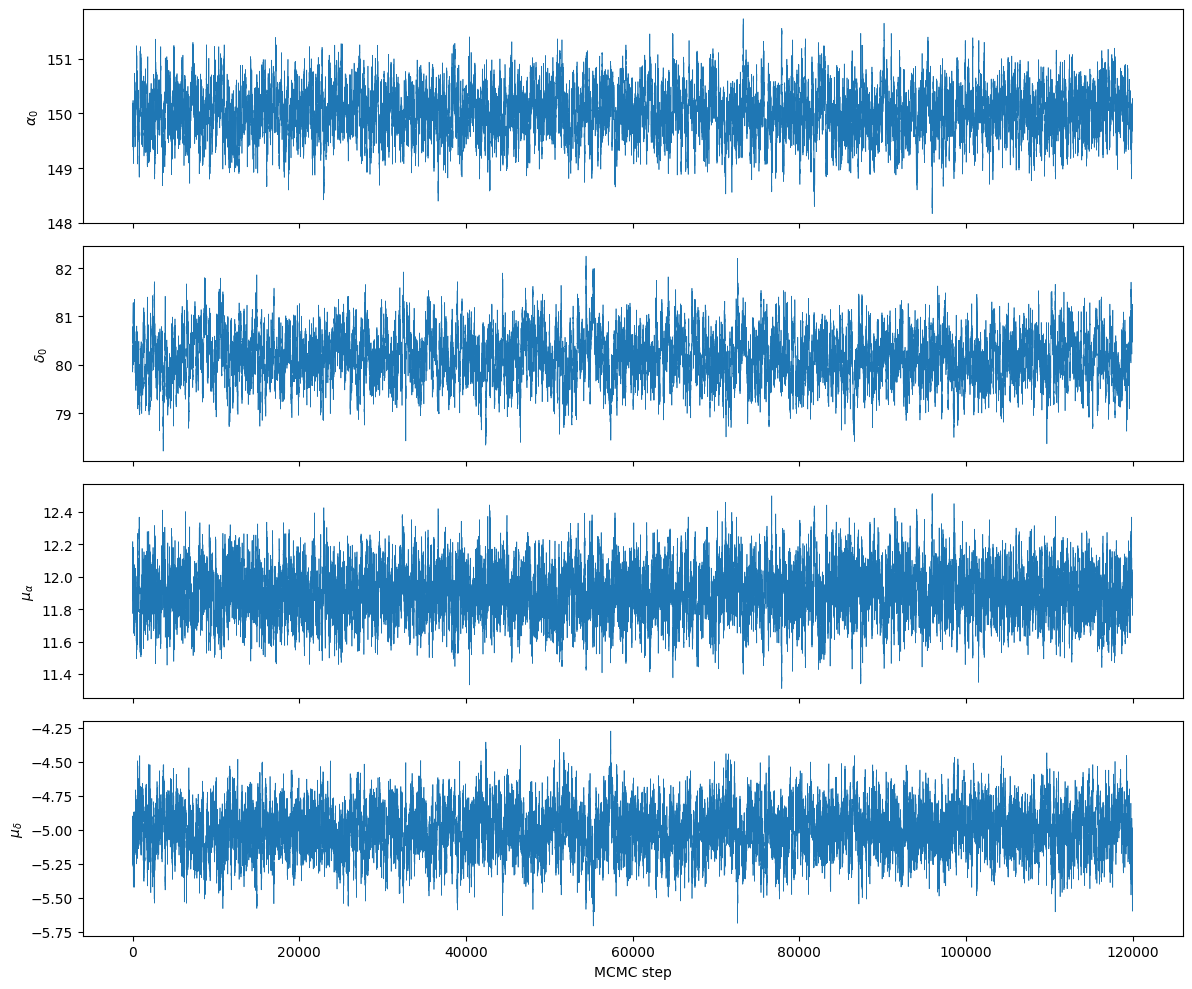

In [ ]:
#trace plots
param_names = [r"$\alpha_0$", r"$\delta_0$", r"$\mu_\alpha$", r"$\mu_\delta$"]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(chain[:, i], lw=0.5)
    ax.set_ylabel(param_names[i])

axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()

In [ ]:
#burn in and posterior:

# Burn-in
burn_in = 20_000

samples_mcmc = chain[burn_in:]
logpost_mcmc = logpost_chain[burn_in:]

print("Posterior sample shape:", samples_mcmc.shape)

Posterior sample shape: (100000, 4)


In [ ]:
# Normalize posterior values for plotting
# These are not analytically normalized over parameter space,
# but they are normalized over the retained MCMC sample and work well for color coding.

logpost_shifted = logpost_mcmc - np.max(logpost_mcmc)
posterior_pdf_mcmc = np.exp(logpost_shifted)
posterior_pdf_mcmc /= np.sum(posterior_pdf_mcmc)

print("Sum of normalized posterior proxy:", posterior_pdf_mcmc.sum())

Sum of normalized posterior proxy: 0.9999999999999999


In [ ]:
posterior_summary_mcmc = {}

for i, name in enumerate(["alpha0", "delta0", "mu_alpha", "mu_delta"]):
    x = samples_mcmc[:, i]

    mean_val = np.mean(x)
    median_val = np.median(x)
    q16, q84 = np.quantile(x, [0.16, 0.84])
    q025, q975 = np.quantile(x, [0.025, 0.975])

    posterior_summary_mcmc[name] = {
        "mean": mean_val,
        "median": median_val,
        "map": samples_mcmc[np.argmax(logpost_mcmc), i],
        "ci68": (q16, q84),
        "ci95": (q025, q975),
        "std": np.std(x, ddof=1)
    }

print("Posterior summaries from MCMC:")
for name, s in posterior_summary_mcmc.items():
    print(
        f"{name:8s}: "
        f"mean={s['mean']:10.4f}, "
        f"median={s['median']:10.4f}, "
        f"MAP={s['map']:10.4f}, "
        f"std={s['std']:8.4f}, "
        f"95% CI=[{s['ci95'][0]:.4f}, {s['ci95'][1]:.4f}]"
    )

Posterior summaries from MCMC:
alpha0  : mean=  150.0191, median=  150.0223, MAP=  150.0248, std=  0.4373, 95% CI=[149.1456, 150.8563]
delta0  : mean=   80.1568, median=   80.1580, MAP=   80.2128, std=  0.4981, 95% CI=[79.1784, 81.1224]
mu_alpha: mean=   11.9026, median=   11.9007, MAP=   11.8963, std=  0.1514, 95% CI=[11.6104, 12.2044]
mu_delta: mean=   -4.9991, median=   -4.9982, MAP=   -5.0164, std=  0.1712, 95% CI=[-5.3358, -4.6667]


In [ ]:
#Extract LS, posterior mean, MAP
alpha0_map, delta0_map, mu_alpha_map, mu_delta_map = samples_mcmc[np.argmax(logpost_mcmc)]

alpha0_mean = posterior_summary_mcmc["alpha0"]["mean"]
delta0_mean = posterior_summary_mcmc["delta0"]["mean"]
mu_alpha_mean = posterior_summary_mcmc["mu_alpha"]["mean"]
mu_delta_mean = posterior_summary_mcmc["mu_delta"]["mean"]

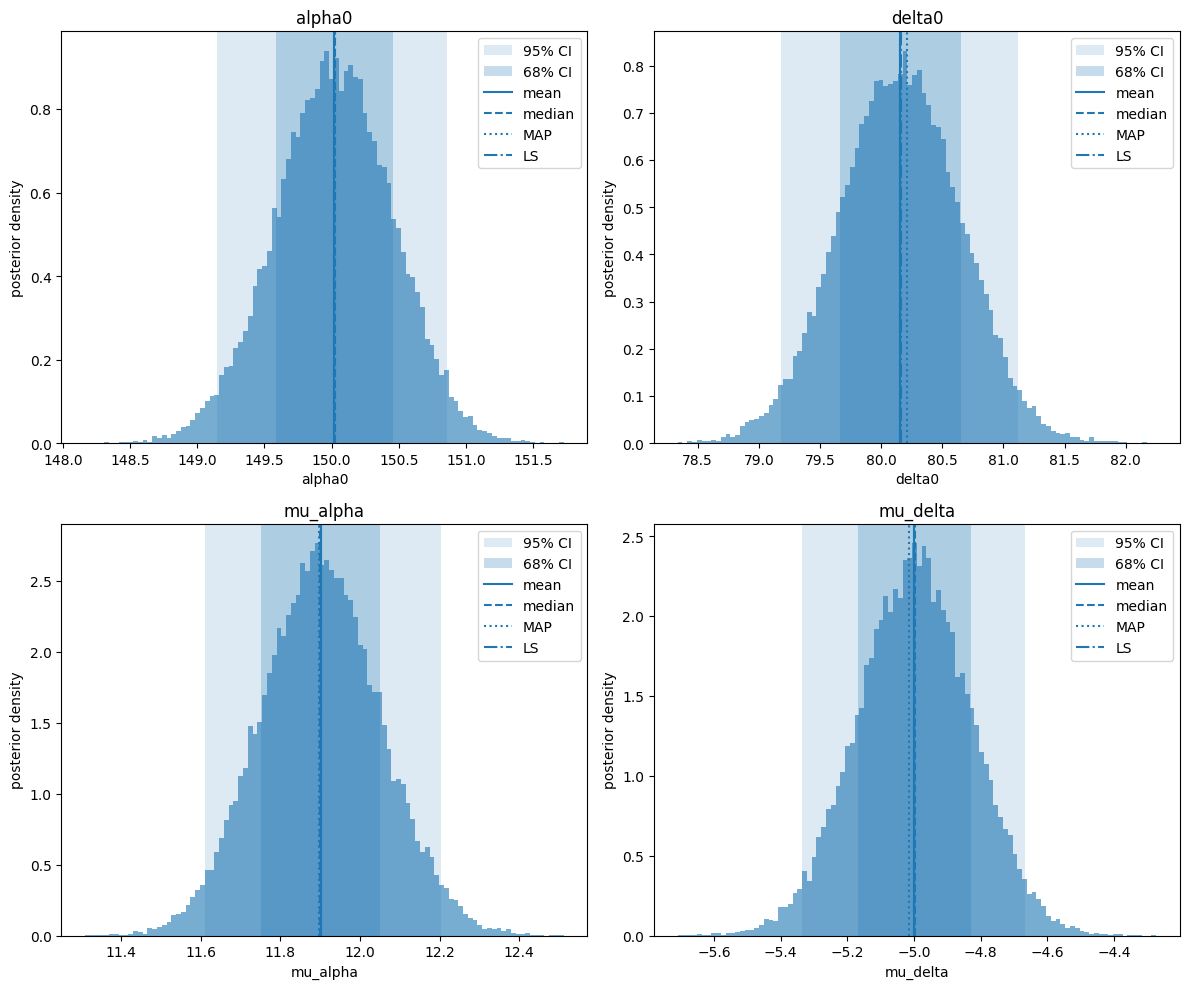

In [ ]:
#Plot posterior distributions of parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

param_names_plain = ["alpha0", "delta0", "mu_alpha", "mu_delta"]
ls_values = [alpha0_hat, delta0_hat, mu_alpha_hat, mu_delta_hat]

for i, ax in enumerate(axes):
    name = param_names_plain[i]
    x = samples_mcmc[:, i]
    s = posterior_summary_mcmc[name]

    ax.hist(x, bins=100, density=True, alpha=0.6)
    ax.axvspan(s["ci95"][0], s["ci95"][1], alpha=0.15, label="95% CI")
    ax.axvspan(s["ci68"][0], s["ci68"][1], alpha=0.25, label="68% CI")

    ax.axvline(s["mean"], label="mean")
    ax.axvline(s["median"], linestyle="--", label="median")
    ax.axvline(s["map"], linestyle=":", label="MAP")
    ax.axvline(ls_values[i], linestyle="-.", label="LS")

    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("posterior density")
    ax.legend()

plt.tight_layout()
plt.show()

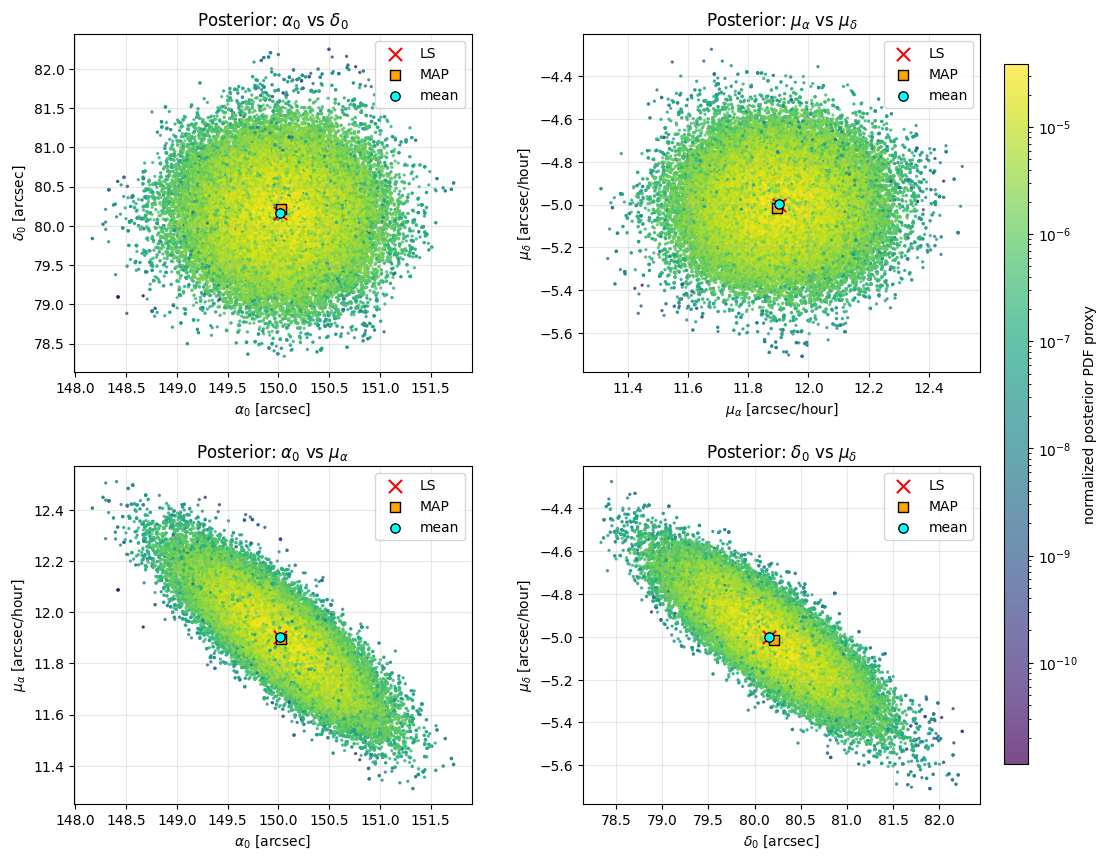

In [ ]:
# Parametric posterior plots color-coded by normalized posterior PDF proxy

from matplotlib.colors import LogNorm

# Keep only positive values for LogNorm
mask = posterior_pdf_mcmc > 0
samples_plot = samples_mcmc[mask]
pdf_plot = posterior_pdf_mcmc[mask]

alpha0_s   = samples_plot[:, 0]
delta0_s   = samples_plot[:, 1]
mu_alpha_s = samples_plot[:, 2]
mu_delta_s = samples_plot[:, 3]

vmin = pdf_plot.min()
vmax = pdf_plot.max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# 1) alpha0 vs delta0
sc = axes[0].scatter(
    alpha0_s, delta0_s,
    c=pdf_plot,
    s=2,
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    alpha=0.7
)
axes[0].scatter(alpha0_hat, delta0_hat, marker="x", s=90, color="red", label="LS")
axes[0].scatter(alpha0_map, delta0_map, marker="s", s=45, color="orange", edgecolor="black", label="MAP")
axes[0].scatter(alpha0_mean, delta0_mean, marker="o", s=45, color="cyan", edgecolor="black", label="mean")
axes[0].set_xlabel(r"$\alpha_0$ [arcsec]")
axes[0].set_ylabel(r"$\delta_0$ [arcsec]")
axes[0].set_title(r"Posterior: $\alpha_0$ vs $\delta_0$")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best")

# 2) mu_alpha vs mu_delta
axes[1].scatter(
    mu_alpha_s, mu_delta_s,
    c=pdf_plot,
    s=2,
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    alpha=0.7
)
axes[1].scatter(mu_alpha_hat, mu_delta_hat, marker="x", s=90, color="red", label="LS")
axes[1].scatter(mu_alpha_map, mu_delta_map, marker="s", s=45, color="orange", edgecolor="black", label="MAP")
axes[1].scatter(mu_alpha_mean, mu_delta_mean, marker="o", s=45, color="cyan", edgecolor="black", label="mean")
axes[1].set_xlabel(r"$\mu_\alpha$ [arcsec/hour]")
axes[1].set_ylabel(r"$\mu_\delta$ [arcsec/hour]")
axes[1].set_title(r"Posterior: $\mu_\alpha$ vs $\mu_\delta$")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best")

# 3) alpha0 vs mu_alpha
axes[2].scatter(
    alpha0_s, mu_alpha_s,
    c=pdf_plot,
    s=2,
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    alpha=0.7
)
axes[2].scatter(alpha0_hat, mu_alpha_hat, marker="x", s=90, color="red", label="LS")
axes[2].scatter(alpha0_map, mu_alpha_map, marker="s", s=45, color="orange", edgecolor="black", label="MAP")
axes[2].scatter(alpha0_mean, mu_alpha_mean, marker="o", s=45, color="cyan", edgecolor="black", label="mean")
axes[2].set_xlabel(r"$\alpha_0$ [arcsec]")
axes[2].set_ylabel(r"$\mu_\alpha$ [arcsec/hour]")
axes[2].set_title(r"Posterior: $\alpha_0$ vs $\mu_\alpha$")
axes[2].grid(alpha=0.3)
axes[2].legend(loc="best")

# 4) delta0 vs mu_delta
axes[3].scatter(
    delta0_s, mu_delta_s,
    c=pdf_plot,
    s=2,
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    alpha=0.7
)
axes[3].scatter(delta0_hat, mu_delta_hat, marker="x", s=90, color="red", label="LS")
axes[3].scatter(delta0_map, mu_delta_map, marker="s", s=45, color="orange", edgecolor="black", label="MAP")
axes[3].scatter(delta0_mean, mu_delta_mean, marker="o", s=45, color="cyan", edgecolor="black", label="mean")
axes[3].set_xlabel(r"$\delta_0$ [arcsec]")
axes[3].set_ylabel(r"$\mu_\delta$ [arcsec/hour]")
axes[3].set_title(r"Posterior: $\delta_0$ vs $\mu_\delta$")
axes[3].grid(alpha=0.3)
axes[3].legend(loc="best")

fig.subplots_adjust(right=0.88, hspace=0.28, wspace=0.28)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("normalized posterior PDF proxy")

plt.show()

In [ ]:
alpha_mean_fit = alpha0_mean + mu_alpha_mean * (t - t0)
delta_mean_fit = delta0_mean + mu_delta_mean * (t - t0)

alpha_map_fit = alpha0_map + mu_alpha_map * (t - t0)
delta_map_fit = delta0_map + mu_delta_map * (t - t0)

alpha_ls = alpha0_hat + mu_alpha_hat * (t - t0)
delta_ls = delta0_hat + mu_delta_hat * (t - t0)

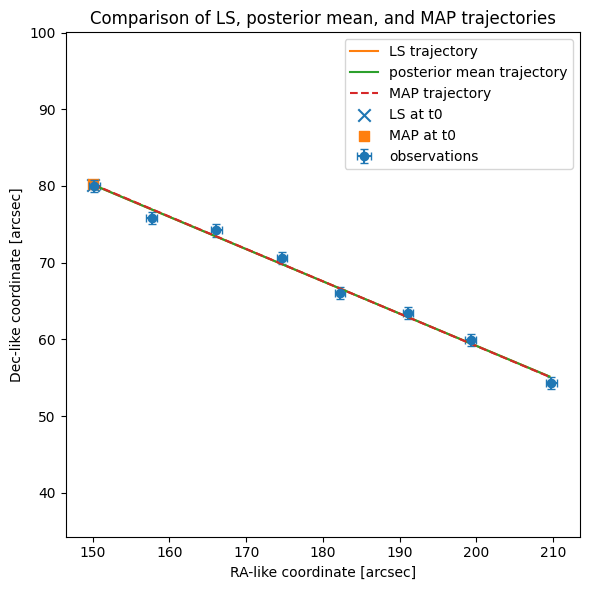

In [ ]:
#Compare LS, posterior mean, MAP in RA-Dec space
plt.figure(figsize=(6, 6))

plt.errorbar(
    alpha_obs, delta_obs,
    xerr=sigma_alpha, yerr=sigma_delta,
    fmt="o", capsize=3, label="observations"
)

plt.plot(alpha_ls, delta_ls, label="LS trajectory")
plt.plot(alpha_mean_fit, delta_mean_fit, label="posterior mean trajectory")
plt.plot(alpha_map_fit, delta_map_fit, linestyle="--", label="MAP trajectory")

plt.scatter(alpha0_hat, delta0_hat, marker="x", s=80, label="LS at t0")
plt.scatter(alpha0_map, delta0_map, marker="s", s=60, label="MAP at t0")

plt.xlabel("RA-like coordinate [arcsec]")
plt.ylabel("Dec-like coordinate [arcsec]")
plt.title("Comparison of LS, posterior mean, and MAP trajectories")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#residuals
alpha_res_mcmc = alpha_obs - alpha_mean_fit
delta_res_mcmc = delta_obs - delta_mean_fit

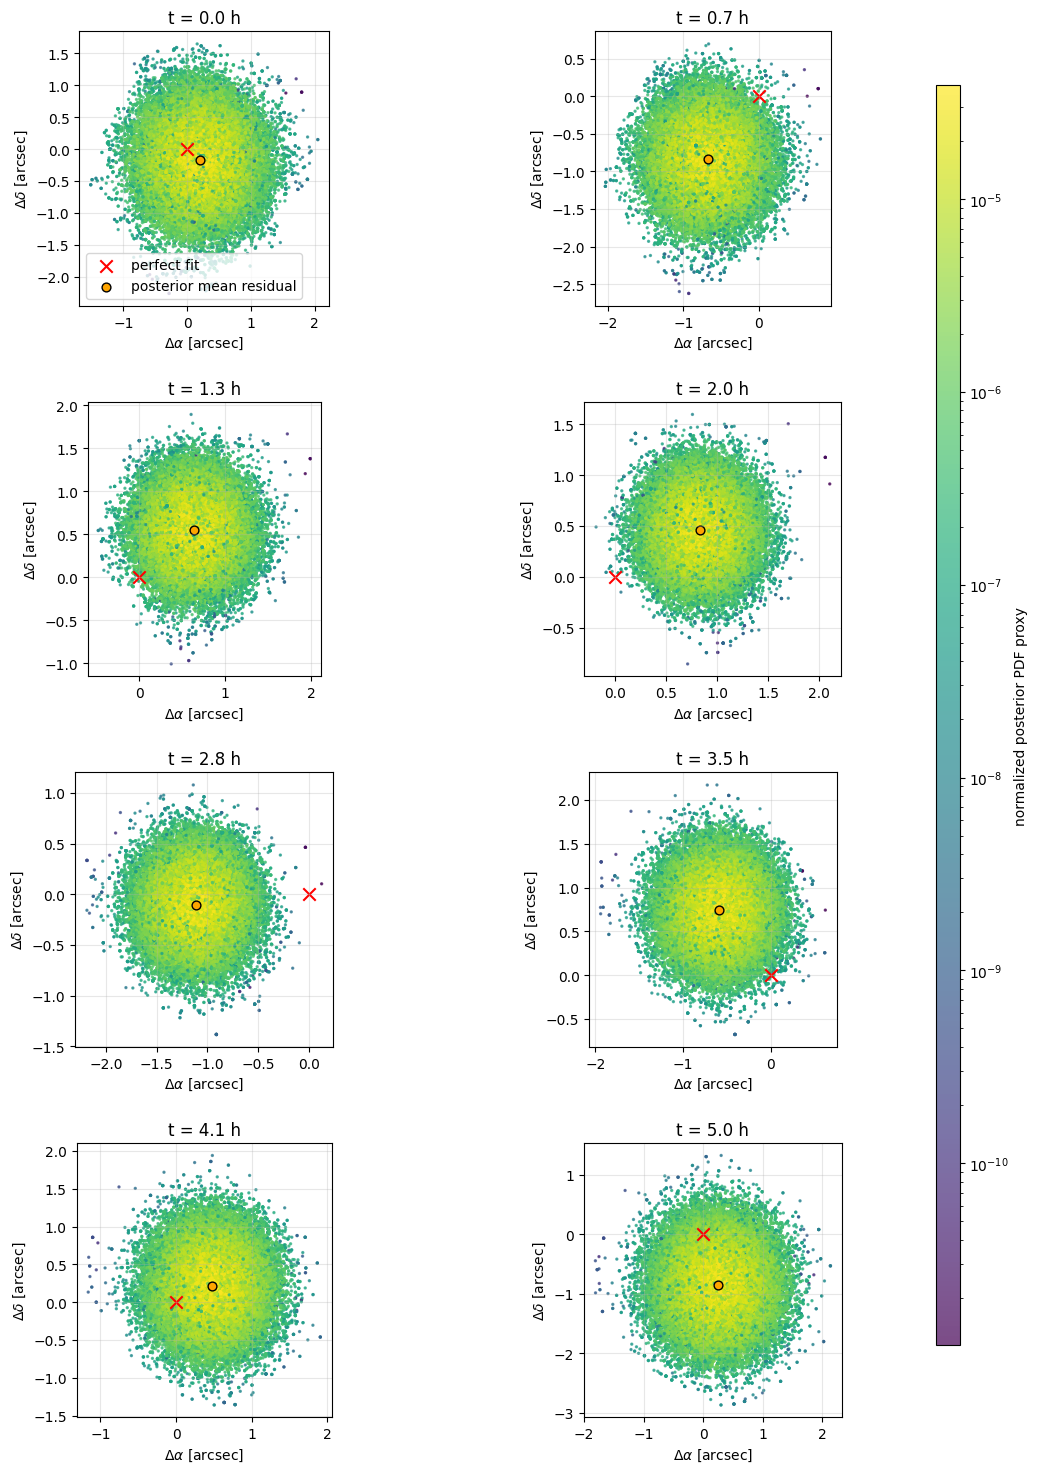

In [ ]:
#On-sky residuals for each observation epoch, color-coded by normalized posterior PDF
# On-sky residuals from the MCMC posterior sample
# residuals = observed - model
# color = normalized posterior PDF proxy
# one panel per timestamp

# Model predictions for all retained MCMC samples
alpha_model_all = samples_mcmc[:, 0][:, None] + samples_mcmc[:, 2][:, None] * (t - t0)[None, :]
delta_model_all = samples_mcmc[:, 1][:, None] + samples_mcmc[:, 3][:, None] * (t - t0)[None, :]

# Residuals for every retained MCMC sample and every epoch
alpha_resid_all = alpha_obs[None, :] - alpha_model_all
delta_resid_all = delta_obs[None, :] - delta_model_all

# Keep only strictly positive pdf values for LogNorm
mask = posterior_pdf_mcmc > 0
alpha_resid_plot = alpha_resid_all[mask]
delta_resid_plot = delta_resid_all[mask]
pdf_plot = posterior_pdf_mcmc[mask]

n_obs = len(t)
ncols = 2
nrows = int(np.ceil(n_obs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 18))
axes = np.atleast_1d(axes).ravel()

vmin = pdf_plot.min()
vmax = pdf_plot.max()

for i in range(n_obs):
    ax = axes[i]

    sc = ax.scatter(
        alpha_resid_plot[:, i],
        delta_resid_plot[:, i],
        c=pdf_plot,
        s=2,
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        alpha=0.7
    )

    ax.scatter(0, 0, marker="x", s=80, color="red", label="perfect fit")
    ax.scatter(
        alpha_res_mcmc[i],
        delta_res_mcmc[i],
        marker="o",
        s=40,
        color="orange",
        edgecolor="black",
        label="posterior mean residual"
    )

    ax.set_title(f"t = {t[i]:.1f} h")
    ax.set_xlabel(r"$\Delta \alpha$ [arcsec]")
    ax.set_ylabel(r"$\Delta \delta$ [arcsec]")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

for j in range(n_obs, len(axes)):
    axes[j].axis("off")

fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.28)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("normalized posterior PDF proxy")

axes[0].legend(loc="best")

plt.show()

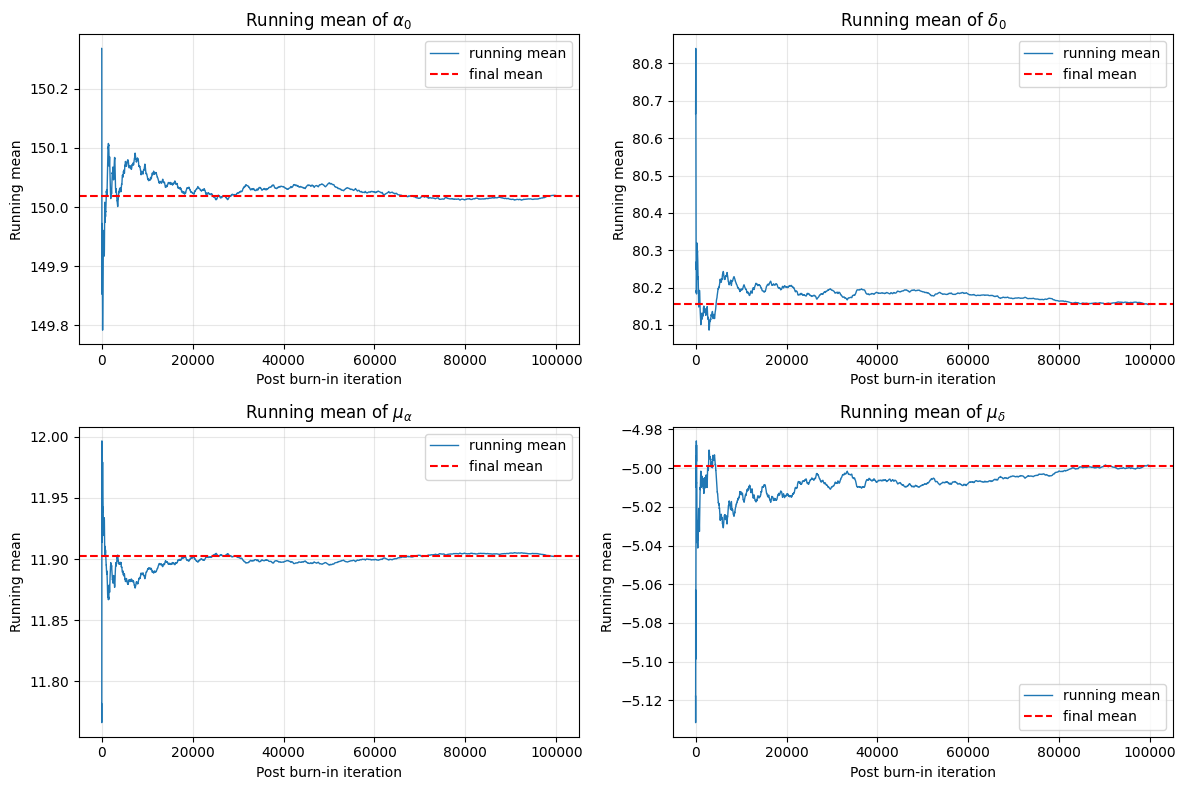

In [ ]:
# Running mean / cumulative mean diagnostic
# This checks whether the posterior mean estimate stabilizes as the chain grows.

param_names = [r"$\alpha_0$", r"$\delta_0$", r"$\mu_\alpha$", r"$\mu_\delta$"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

n = samples_mcmc.shape[0]
x = np.arange(1, n + 1)

for i, ax in enumerate(axes):
    running_mean = np.cumsum(samples_mcmc[:, i]) / x

    ax.plot(x, running_mean, lw=1.0, label="running mean")
    ax.axhline(np.mean(samples_mcmc[:, i]), color="red", linestyle="--", label="final mean")

    ax.set_title(f"Running mean of {param_names[i]}")
    ax.set_xlabel("Post burn-in iteration")
    ax.set_ylabel("Running mean")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

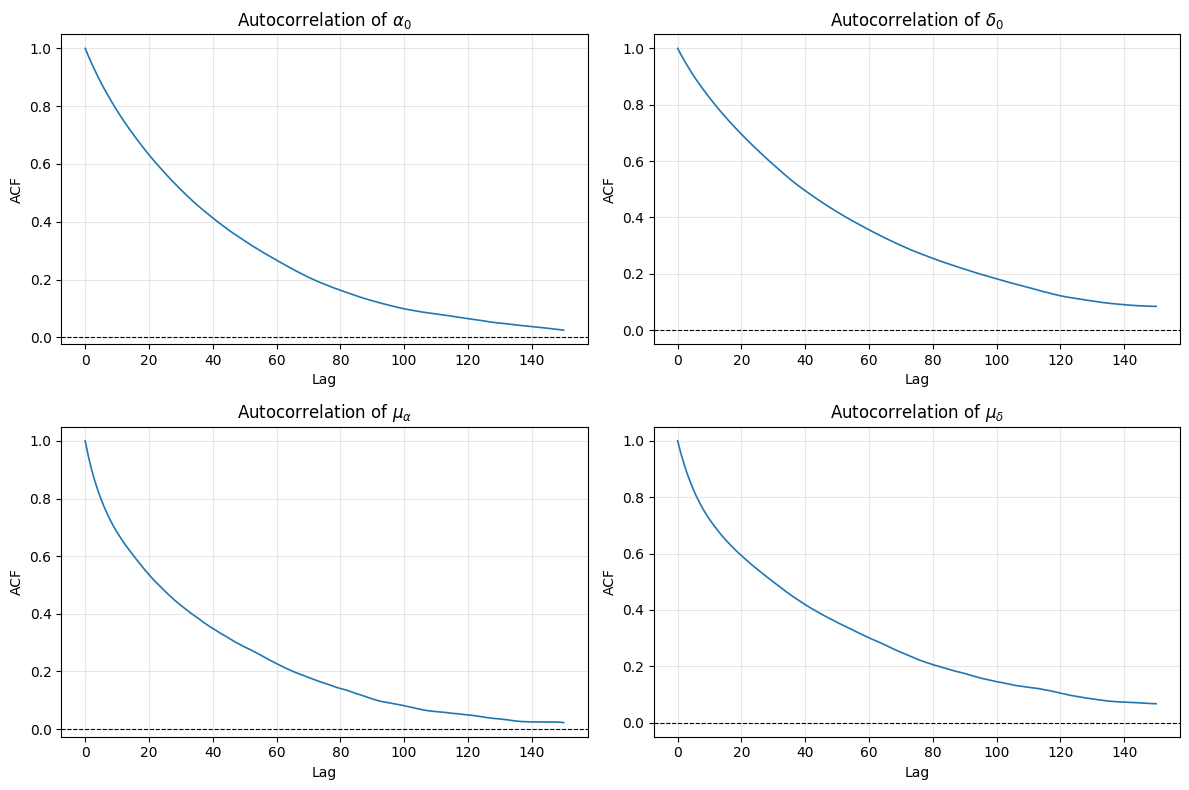

In [ ]:
# Autocorrelation diagnostic
# This checks how strongly correlated neighboring MCMC samples are.

def autocorrelation(x, max_lag=200):
    """
    Compute autocorrelation function up to max_lag.
    """
    x = np.asarray(x)
    x = x - np.mean(x)
    var = np.var(x)

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0

    for lag in range(1, max_lag + 1):
        acf[lag] = np.sum(x[:-lag] * x[lag:]) / ((len(x) - lag) * var)

    return acf

max_lag = 150

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    acf = autocorrelation(samples_mcmc[:, i], max_lag=max_lag)

    ax.plot(np.arange(max_lag + 1), acf, lw=1.2)
    ax.axhline(0, color="black", linestyle="--", lw=0.8)

    ax.set_title(f"Autocorrelation of {param_names[i]}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Simple convergence / efficiency summary

print(f"Acceptance rate: {accepted.mean():.3f}")

def effective_sample_size(x, max_lag=200):
    """
    Very simple ESS estimate from the autocorrelation function.
    """
    acf = autocorrelation(x, max_lag=max_lag)

    # initial positive sequence approximation
    positive_acf = acf[1:]
    positive_acf = positive_acf[positive_acf > 0]

    tau = 1 + 2 * np.sum(positive_acf)
    ess = len(x) / tau
    return ess

print("\nApproximate effective sample sizes:")
for i, name in enumerate(["alpha0", "delta0", "mu_alpha", "mu_delta"]):
    ess = effective_sample_size(samples_mcmc[:, i], max_lag=150)
    print(f"{name:8s}: ESS ≈ {ess:.1f}")

Acceptance rate: 0.521

Approximate effective sample sizes:
alpha0  : ESS ≈ 1172.9
delta0  : ESS ≈ 938.8
mu_alpha: ESS ≈ 1367.4
mu_delta: ESS ≈ 1098.5
